<a href="https://colab.research.google.com/github/hariharan0493/Task2_Submission/blob/main/Cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pickle
import numpy as np
import pandas as pd

In [3]:
#device configuration
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
#Parameters
num_classes = 10
num_epochs = 15
batch_size = 64
learning_rate = 0.01
momentum=0.9

In [5]:
# dataset has PILImage images.
# Transforming them to tensors
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [6]:
#CIFAR10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                           train=True,
                                           transform=transform,
                                           download=False)

test_dataset = torchvision.datasets.CIFAR10(root='./data',
                                          train=False,
                                          transform=transform,
                                            download=False)

In [7]:
#Data loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

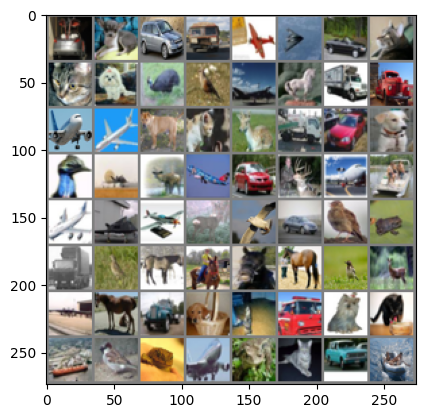

In [ ]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

In [8]:
class ResidualBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()

    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                          stride=stride, padding=1)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU(inplace=True)

    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                            stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(out_channels)

    # Skip connection
    self.shortcut = nn.Sequential()

    if stride != 1 or in_channels != out_channels:
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=1, stride=stride),
            nn.BatchNorm2d(out_channels)
        )

  def forward(self, x):
    identity = self.shortcut(x)

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)

    out += identity
    out = self.relu(out)

    return out

class ResNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.stage1=nn.Sequential(
        ResidualBlock(3,64),
        ResidualBlock(64,64),
    )
    self.stage2=nn.Sequential(
        ResidualBlock(64,128,stride=2),
        ResidualBlock(128,128),
    )

    self.avgpool=nn.AdaptiveAvgPool2d((1,1))
    self.fc=nn.Linear(128,10)

  def forward(self,x):
    x=self.stage1(x)
    x=self.stage2(x)

    x=self.avgpool(x)
    x=x.view(x.size(0),-1)

    x=self.fc(x)

    return x



In [9]:
model =ResNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate,momentum=momentum)

In [10]:
#Lists
train_losses=list()
train_accuracies=list()
val_losses=list()
val_accuracies=list()

In [11]:
#Train the model
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
  n_correct = 0
  n_samples = 0
  for i, (images, labels) in enumerate(train_loader):
    # origin shape: [64, 3, 32, 32] = 4, 3, 1024
    # input_layer: 3 input channels, 6 output channels, 5 kernel size
    images = images.to(device)
    labels = labels.to(device)

    # Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    _,predict = torch.max(outputs.data, 1)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i+1) % 100 == 0:
      print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

      _,predict = torch.max(outputs.data, 1)
      n_samples += labels.size(0)
      n_correct += (predict == labels).sum().item()

  train_acc = 100 * n_correct/n_samples
  train_loss=loss.item()

# Test the model
  with torch.no_grad():
    n_correct = 0
    n_samples = 0
    val_loss=0
    n_class_correct = [0 for i in range(10)]
    n_class_samples = [0 for i in range(10)]
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

        # max returns (value ,index)
        _, predicted = torch.max(outputs.data, 1)
        #loss for current batch
        loss=criterion(outputs,labels)
        val_loss += loss.item()

        for i in range(labels.size(0)):
          label = labels[i]
          pred = predicted[i]
          if (label == pred):
            n_class_correct[label] += 1
            n_class_samples[label] += 1

    val_acc = 100.0 * n_correct / n_samples
    val_loss = val_loss/len(test_loader)

    print(f'Epoch [{epoch+1}/{num_epochs}],Train_acc: {train_acc:.4f}%,Train_loss:{train_loss:.4f},Val_acc:{val_acc}%,Val_loss:{val_loss:.4f}')

    #save the values to list
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)

print('Finished Training')
PATH = './cnn.pth'
torch.save(model.state_dict(), PATH)


Epoch [1/15], Step [100/782], Loss: 1.6647
Epoch [1/15], Step [200/782], Loss: 1.5752
Epoch [1/15], Step [300/782], Loss: 1.2721
Epoch [1/15], Step [400/782], Loss: 1.3206
Epoch [1/15], Step [500/782], Loss: 1.1579
Epoch [1/15], Step [600/782], Loss: 1.2007
Epoch [1/15], Step [700/782], Loss: 1.2604
Epoch [1/15],Train_acc: 50.8929%,Train_loss:0.7623,Val_acc:60.22%,Val_loss:1.0736
Epoch [2/15], Step [100/782], Loss: 1.1267
Epoch [2/15], Step [200/782], Loss: 1.0429
Epoch [2/15], Step [300/782], Loss: 0.9440
Epoch [2/15], Step [400/782], Loss: 0.7737
Epoch [2/15], Step [500/782], Loss: 1.1242
Epoch [2/15], Step [600/782], Loss: 0.8102
Epoch [2/15], Step [700/782], Loss: 0.7717
Epoch [2/15],Train_acc: 65.4018%,Train_loss:0.8913,Val_acc:68.18%,Val_loss:0.8927
Epoch [3/15], Step [100/782], Loss: 1.1079
Epoch [3/15], Step [200/782], Loss: 0.9630
Epoch [3/15], Step [300/782], Loss: 0.9617
Epoch [3/15], Step [400/782], Loss: 0.6371
Epoch [3/15], Step [500/782], Loss: 0.4853
Epoch [3/15], Step 

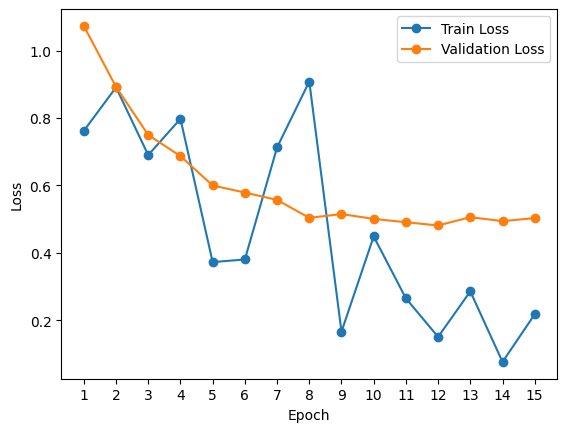

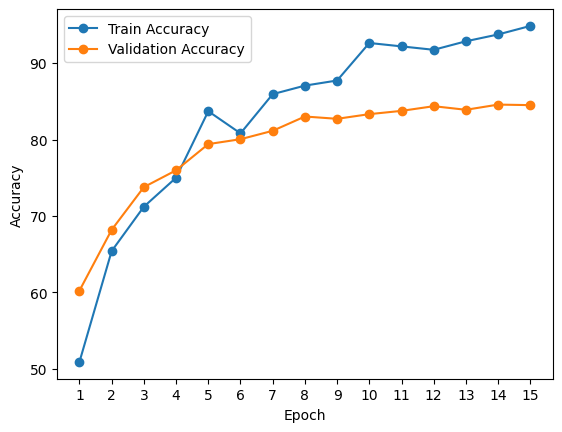

In [12]:
#graphs

epochs = range(1, num_epochs + 1)

#losses
plt.plot(epochs, train_losses, marker='o',label='Train Loss')
plt.plot(epochs, val_losses, marker='o',label='Validation Loss')

plt.xticks(list(epochs))

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#accuracies
plt.plot(epochs, train_accuracies, marker='o',label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='o',label='Validation Accuracy')

plt.xticks(list(epochs))

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [13]:
#Dump weigths
import pickle

with open("model_weights.pkl", "wb") as f:
    pickle.dump(model.state_dict(), f)

In [15]:
# Generate submission.csv
predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        predictions.extend(predicted.cpu().numpy())

submission = pd.DataFrame({
    'id': range(len(predictions)),
    'prediction': predictions
})

submission.to_csv('submission.csv', index=False)

print("submission.csv generated successfully!")
print(submission.head())

submission.csv generated successfully!
   id  prediction
0   0           3
1   1           8
2   2           8
3   3           0
4   4           6


In [16]:
from google.colab import files

files.download("model_weights.pkl")
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>